Load dataset

In [24]:
import pandas as pd

train_df = pd.read_parquet("../data/processed/train_split_no_fss.parquet")

In [25]:
test_df = pd.read_parquet("../data/processed/test_split_no_fss.parquet")

In [26]:
X_train = train_df["Consumer complaint narrative"]
y_train = train_df["Product"]

In [32]:
X_test = test_df["Consumer complaint narrative"]
y_test = test_df["Product"]

In [27]:
import re

def remove_mask_tokens(text):
    return re.sub(r"\bx+\b", " ", text.lower())

X_train = train_df["Consumer complaint narrative"].apply(remove_mask_tokens)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

TF-IDF + Logistic Regression (with class_weight)

In [37]:
lr_tfidf_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        max_features=200000,
        token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        verbose=1
    ))
])

In [38]:
lr_tfidf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


Predictions

In [ ]:
y_pred = lr_tfidf_model.predict(X_test)

Model Evaluation

In [40]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.8605624115775107

Classification report:
                                      precision    recall  f1-score   support

                       Bank Accounts     0.7686    0.8319    0.7990     13761
                      Consumer Loans     0.3673    0.6150    0.4599      3195
                    Credit Reporting     0.9802    0.8726    0.9233    188824
             Credit or Prepaid Cards     0.6710    0.8222    0.7389     17297
                     Debt collection     0.6711    0.8309    0.7425     30468
Money Transfers and Digital Payments     0.8140    0.8375    0.8256      8503
                            Mortgage     0.8383    0.9373    0.8850     10518
                        Student loan     0.6755    0.9093    0.7752      4455
               Vehicle loan or lease     0.3996    0.7628    0.5245      3592

                            accuracy                         0.8606    280613
                           macro avg     0.6873    0.8244    0.7415    280613
         

Confusion Matrix

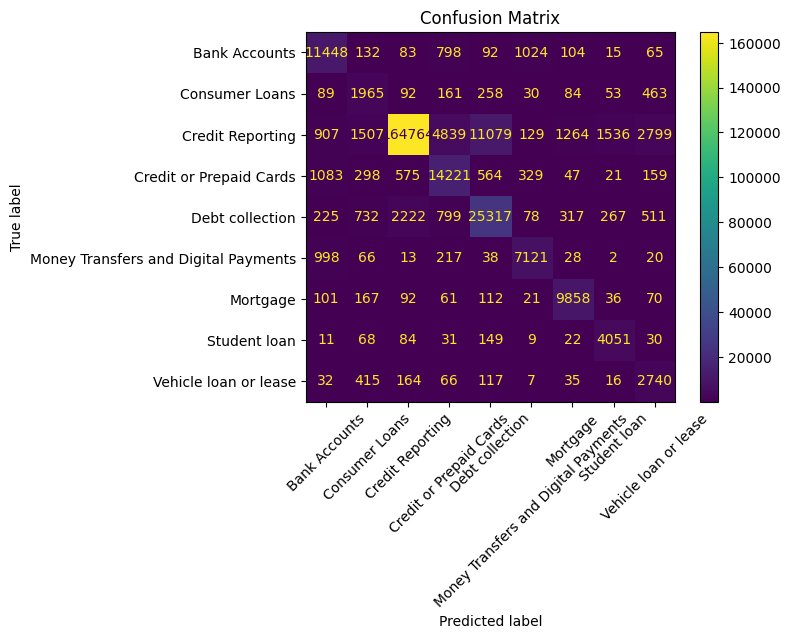

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=lr_tfidf_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_tfidf_model.classes_)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

TF-IDF + Logistic Regression (without class_weight)

In [43]:
lr_tfidf_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
        min_df=3,
        max_df=0.9,
        max_features=200000,
        token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        verbose=1
    ))
])

In [44]:
lr_tfidf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [45]:
y_pred = lr_tfidf_model.predict(X_test)

Model Evaluation

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.9011307387754666

Classification report:
                                      precision    recall  f1-score   support

                       Bank Accounts     0.7967    0.8355    0.8157     13761
                      Consumer Loans     0.6552    0.4288    0.5184      3195
                    Credit Reporting     0.9390    0.9648    0.9517    188824
             Credit or Prepaid Cards     0.7978    0.7697    0.7835     17297
                     Debt collection     0.8101    0.7410    0.7740     30468
Money Transfers and Digital Payments     0.8669    0.8017    0.8330      8503
                            Mortgage     0.9021    0.9023    0.9022     10518
                        Student loan     0.8696    0.7886    0.8271      4455
               Vehicle loan or lease     0.6842    0.5869    0.6318      3592

                            accuracy                         0.9011    280613
                           macro avg     0.8135    0.7577    0.7819    280613
         

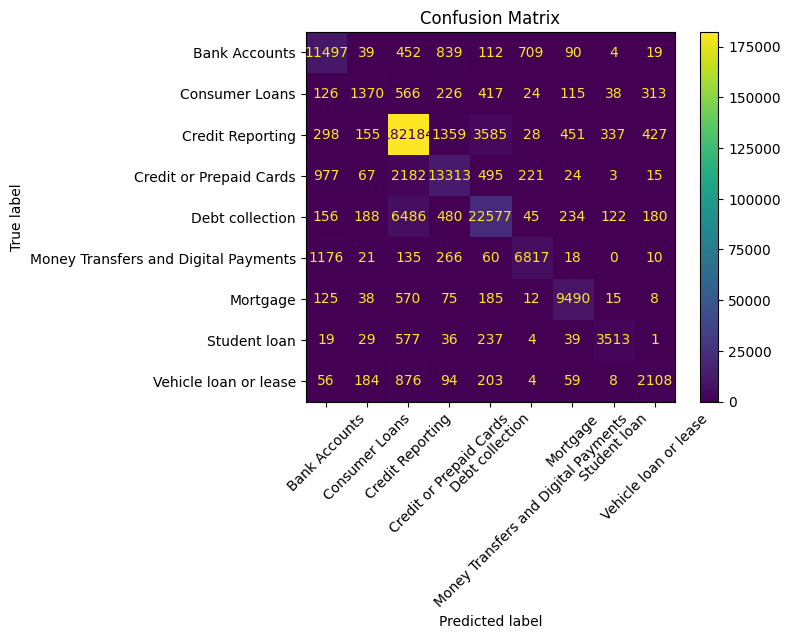

In [48]:
cm = confusion_matrix(y_test, y_pred, labels=lr_tfidf_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_tfidf_model.classes_)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()